In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from multicam.multicam import MultiCAM
import sham

TNG_H = 0.6774
COLOR_CUT = 1.0  # Changed a little bit

# -----------------------------
# Load data
# -----------------------------
hydro_full = pd.read_csv(
    'Data/cache_files/hydro_color_tree_subhaloflag_check_data.csv',
    usecols=[
        'SubhaloMass', 'StellarMass', 'x', 'y', 'z',
        'logStellarMass', 'logSubhaloMass', 'g-i',
        'vpeak', 'a12', 'mpeak',
        *[f'mpeak_mah{ii}' for ii in range(100)]
    ]
)

# Stellar mass cut
hydro_full = hydro_full[
    hydro_full['StellarMass'] >= (1.4e8 * TNG_H)
]

# Add z12
hydro_full['z12'] = (1 / hydro_full['a12']) - 1

# mpeak cut
hydro_data_mpeak_cut = hydro_full[
    (hydro_full['mpeak'] >= 1e11) &
    (hydro_full['mpeak'] <= 1e12)
]

# -----------------------------
# Define SHAM baseline
# -----------------------------
log10_mpeak = np.log10(hydro_data_mpeak_cut['mpeak'].values)
log10_stellar_mass = np.log10(hydro_data_mpeak_cut['StellarMass'].values)

# SHAM mean relation (NO scatter)
logmstar_sham = sham.sham(
    log10_mpeak,
    log10_stellar_mass  # if your implementation requires it
)

# -----------------------------
# MultiCAM targets & features
# -----------------------------
color = hydro_data_mpeak_cut['g-i'].values
targets = np.vstack([color]).T

features = np.array([
    hydro_data_mpeak_cut[f'mpeak_mah{ii}'].values
    for ii in range(100)
]).T

# -----------------------------
# Train MultiCAM
# -----------------------------
model = MultiCAM(n_features=100, n_targets=1)
model.fit(features, targets)

# -----------------------------
# Predict & reconstruct M*
# -----------------------------
pred = model.predict(features)

In [2]:
## Compute TPCF ###
from halotools.mock_observables import return_xyz_formatted_array, tpcf_jackknife

def generate_randoms(Lbox, number):
    """Generate randoms to be used for tpcf_jackknife
    Args:
        Lbox: size of TNG simulation box
        number: desired number of randoms, i.e. 10,000
    Return:
        Nran: xyz formatted array of uniform random variables
    """
    Xran = np.random.uniform(0, Lbox, number)
    Yran = np.random.uniform(0, Lbox, number)
    Zran = np.random.uniform(0, Lbox, number)
    Nran = return_xyz_formatted_array(Xran, Yran, Zran)
    return Nran


hydro_mstar_cut = hydro_full[(np.log10(hydro_full['StellarMass']) > 9.5) & (np.log10(hydro_full['StellarMass']) < 10.2)]

# Note use mpeak_cut cause that's what we apply mcam to
hydro_data_mpeak_cut['pred_color'] = pred[:, 0]
hydro_mstar_pred = hydro_data_mpeak_cut[(logmstar_sham > 9.5) & (logmstar_sham < 10.2)]

Lbox = 110.7 * TNG_H
rbins = np.logspace(np.log10(0.1), np.log10(24.9), 16)
rbin_centers = 0.5 * (rbins[1:] + rbins[:-1])
randoms = generate_randoms(Lbox, 50000)

/tmp/ipykernel_8911/223233627.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hydro_data_mpeak_cut['pred_color'] = pred[:, 0]


In [3]:
print(len(hydro_mstar_cut), len(hydro_mstar_pred))

4054 4001


In [4]:
xi_truth, cov_truth = tpcf_jackknife(
        return_xyz_formatted_array(hydro_mstar_cut['x'], hydro_mstar_cut['y'], hydro_mstar_cut['z']),
        randoms, rbins, Nsub=3, period=Lbox, num_threads='max')

xi_pred, cov_pred = tpcf_jackknife(
        return_xyz_formatted_array(hydro_mstar_pred['x'], hydro_mstar_pred['y'], hydro_mstar_pred['z']),
        randoms, rbins, Nsub=3, period=Lbox, num_threads='max')

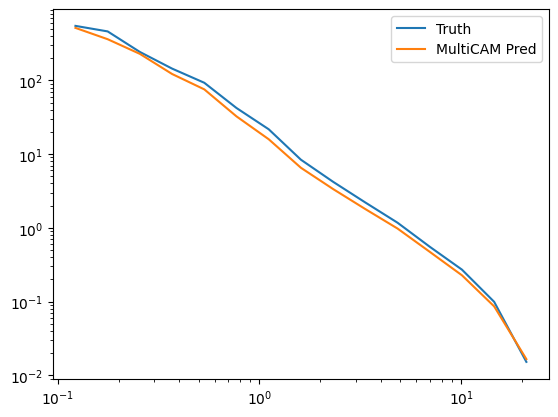

In [5]:
plt.plot(rbin_centers, xi_truth, label = "Truth")
plt.plot(rbin_centers, xi_pred, label = "MultiCAM Pred")
plt.yscale("log")
plt.xscale("log")
plt.legend()

In [6]:
red_pred = hydro_mstar_pred[hydro_mstar_pred['pred_color'] > COLOR_CUT]
blue_pred = hydro_mstar_pred[hydro_mstar_pred['pred_color'] <= COLOR_CUT]

red_table = hydro_mstar_cut[hydro_mstar_cut['g-i'] > COLOR_CUT]
blue_table = hydro_mstar_cut[hydro_mstar_cut['g-i'] <= COLOR_CUT]

print(len(red_pred), len(blue_pred), len(red_table), len(blue_table))

533 3468 983 3071


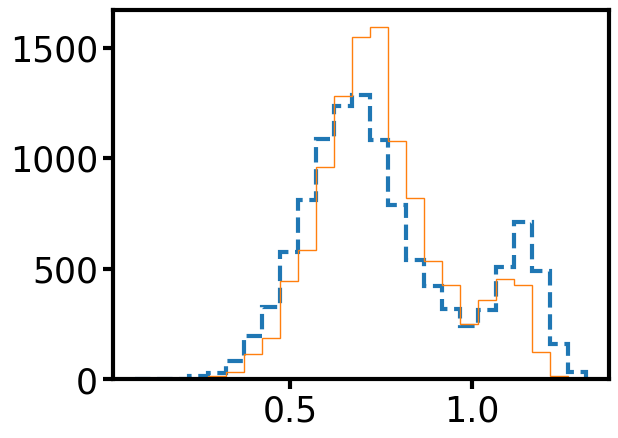

In [19]:
_, bins, _ =plt.hist(hydro_data_mpeak_cut["g-i"], bins = 25, histtype = "step", linestyle = "--", linewidth = 3)
plt.hist(hydro_data_mpeak_cut['pred_color'], bins = bins, histtype = "step")
plt.show()

In [7]:
print(np.min(hydro_mstar_cut['x']), np.max(hydro_mstar_cut['x']))

0.008471757 74.99456


In [8]:
print(Lbox)

74.98818


In [9]:
print(np.min(randoms), np.max(randoms))

0.0010940947257088065 74.9870984702446


In [10]:
## Compute TPCF ###
from halotools.mock_observables import return_xyz_formatted_array, tpcf_jackknife

Lbox = 110.7 * TNG_H
rbins = np.logspace(np.log10(0.1), np.log10(24.9), 16)
rbin_centers = 0.5 * (rbins[1:] + rbins[:-1])
randoms = generate_randoms(Lbox, 50000)


xi_red_truth, cov_red_truth = tpcf_jackknife(
        return_xyz_formatted_array(red_table['x'], red_table['y'], red_table['z']),
        randoms, rbins, Nsub=3, period=Lbox, num_threads='max')

xi_blue_truth, cov_blue_truth = tpcf_jackknife(
        return_xyz_formatted_array(blue_table['x'], blue_table['y'], blue_table['z']),
        randoms, rbins, Nsub=3, period=Lbox, num_threads='max')

xi_red_pred, cov_red_pred = tpcf_jackknife(
        return_xyz_formatted_array(red_pred['x'], red_pred['y'], red_pred['z']),
        randoms, rbins, Nsub=3, period=Lbox, num_threads='max')

xi_blue_pred, cov_blue_pred = tpcf_jackknife(
        return_xyz_formatted_array(blue_pred['x'], blue_pred['y'], blue_pred['z']),
        randoms, rbins, Nsub=3, period=Lbox, num_threads='max')

/home/haley/miniconda3/envs/mcam/lib/python3.11/site-packages/halotools/mock_observables/pair_counters/npairs_jackknife_3d.py:243: UserWarning: Warning: sample1 does not contain points in every jackknife sample.
  warn("Warning: sample1 does not contain points in every jackknife sample.")
/home/haley/miniconda3/envs/mcam/lib/python3.11/site-packages/halotools/mock_observables/pair_counters/npairs_jackknife_3d.py:245: UserWarning: Warning: sample2 does not contain points in every jackknife sample.
  warn("Warning: sample2 does not contain points in every jackknife sample.")


In [11]:
print(np.min(red_table['x']), np.max(red_table['x']))

print(np.min(blue_table['x']), np.max(blue_table['x']))

print(np.min(red_pred['x']), np.max(red_pred['x']))

print(np.min(blue_pred['x']), np.max(blue_pred['x']))

0.0937326 74.98457
0.008471757 74.99456
0.035618078 74.98457
0.02435268 74.99456


In [12]:
print(Lbox)

74.98818


In [13]:
print(np.min(randoms), np.max(randoms))

0.00024305560467887362 74.98802943120208


## Cam

In [14]:
import cam
low = 9.5
high = 10.2
color_bin_cam, color_pred_cam, mask_gal, mask_halo = cam.cam(
        np.log10(hydro_full['mpeak'].to_numpy()), 
        np.log10(hydro_full['StellarMass'].to_numpy()), 
        hydro_full['z12'].to_numpy(), 
        hydro_full['g-i'].to_numpy(), 
        low, high)

In [15]:
halo_bin = hydro_full[mask_halo].copy()
hydro_bin = hydro_full[mask_gal].copy()
halo_bin['color_pred_cam'] = color_pred_cam
hydro_bin['color'] = color_bin_cam
halo_bin

,SubhaloMass,StellarMass,x,y,z,logSubhaloMass,logStellarMass,vpeak,a12,mpeak,...,mpeak_mah93,mpeak_mah94,mpeak_mah95,mpeak_mah96,mpeak_mah97,mpeak_mah98,mpeak_mah99,g-i,z12,color_pred_cam
22,4.092979e+11,1.634936e+10,1.857714,25.990385,19.931873,11.612040,10.213501,219.66856,0.344828,5.439045e+11,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.041630,1.90,1.060976
26,3.041727e+11,1.426524e+10,0.822764,26.144829,19.978884,11.483120,10.154279,198.72200,0.290698,3.719824e+11,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.093975,2.44,1.153974
27,2.883535e+11,8.203994e+09,1.252321,26.284533,19.722652,11.459926,9.914025,155.84532,0.354610,2.919132e+11,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.535936,1.82,0.947378
28,3.212165e+11,1.061568e+10,0.617334,26.386446,19.905940,11.506798,10.025948,161.09685,0.444444,4.735706e+11,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.061354,1.25,0.766253
29,3.033128e+11,1.394747e+10,0.964003,27.382607,17.868130,11.481891,10.144496,200.30531,0.322581,4.341942e+11,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.086931,2.10,1.104876
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39330,1.196596e+11,5.075468e+09,8.193717,38.069378,26.611917,11.077948,9.705476,145.23163,0.400000,3.309459e+11,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.910683,1.50,0.831392
40180,1.318226e+11,7.648536e+09,12.185365,49.848890,48.857555,11.119989,9.883578,185.76553,0.249377,2.747728e+11,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.168732,3.01,1.182709
40381,1.401626e+11,5.255136e+09,38.820156,69.901560,38.579685,11.146632,9.720584,154.96550,0.344828,2.256785e+11,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.160772,1.90,1.060375
40431,1.379732e+11,4.158778e+09,32.970360,1.496312,70.444360,11.139794,9.618966,137.68964,0.465116,2.219580e+11,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.996534,1.15,0.733967


In [16]:
import numpy as np
from halotools.mock_observables import tpcf_jackknife
from halotools.mock_observables import return_xyz_formatted_array

# ---------------------------------------------------
# Color split
# ---------------------------------------------------

halo_bin['red_pred_cam'] = halo_bin['color_pred_cam'].where(
    halo_bin['color_pred_cam'] > COLOR_CUT
)

halo_bin['blue_pred_cam'] = halo_bin['color_pred_cam'].where(
    halo_bin['color_pred_cam'] <= COLOR_CUT
)


# ---------------------------------------------------
# Random catalog
# ---------------------------------------------------

def generate_randoms(Lbox, number):
    """Generate randoms for tpcf_jackknife."""
    Xran = np.random.uniform(0, Lbox, number)
    Yran = np.random.uniform(0, Lbox, number)
    Zran = np.random.uniform(0, Lbox, number)
    return return_xyz_formatted_array(Xran, Yran, Zran)

randoms = generate_randoms(Lbox, 50_000)
print("\nGenerated 50000 randoms.")

# ---------------------------------------------------
# Masks (correct NaN handling)
# ---------------------------------------------------

mask_red = halo_bin['red_pred_cam'].notna()
mask_blue = halo_bin['blue_pred_cam'].notna()

# ---------------------------------------------------
# Build xyz arrays
# ---------------------------------------------------

xyz_red = return_xyz_formatted_array(
    halo_bin.loc[mask_red, 'x'].to_numpy(),
    halo_bin.loc[mask_red, 'y'].to_numpy(),
    halo_bin.loc[mask_red, 'z'].to_numpy(),
)

xyz_blue = return_xyz_formatted_array(
    halo_bin.loc[mask_blue, 'x'].to_numpy(),
    halo_bin.loc[mask_blue, 'y'].to_numpy(),
    halo_bin.loc[mask_blue, 'z'].to_numpy(),
)

# ---------------------------------------------------
# Two-point correlation functions
# ---------------------------------------------------

xi_red_cam, cov_red_cam = tpcf_jackknife(
    xyz_red,
    randoms,
    rbins,
    Nsub=3,
    period=Lbox,
    num_threads='max'
)

xi_blue_cam, cov_blue_cam = tpcf_jackknife(
    xyz_blue,
    randoms,
    rbins,
    Nsub=3,
    period=Lbox,
    num_threads='max'
)



Generated 50000 randoms.


In [17]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# Set global font size for all text elements (optional, can be overridden)
mpl.rcParams['font.size'] = 20

# Set global font size for axis labels
mpl.rcParams['axes.labelsize'] = 25

# Set global font size for tick numbers
mpl.rcParams['xtick.labelsize'] = 25
mpl.rcParams['ytick.labelsize'] = 25

# Set tick widths and sizes globally
mpl.rcParams['xtick.major.width'] = 3
mpl.rcParams['ytick.major.width'] = 3
mpl.rcParams['xtick.minor.width'] = 3
mpl.rcParams['ytick.minor.width'] = 3

mpl.rcParams['xtick.minor.size'] = 6
mpl.rcParams['ytick.minor.size'] = 6
mpl.rcParams['xtick.major.size'] = 7
mpl.rcParams['ytick.major.size'] = 7

# Set axes line width globally
mpl.rcParams['axes.linewidth'] = 3 # Sets the width of the spines

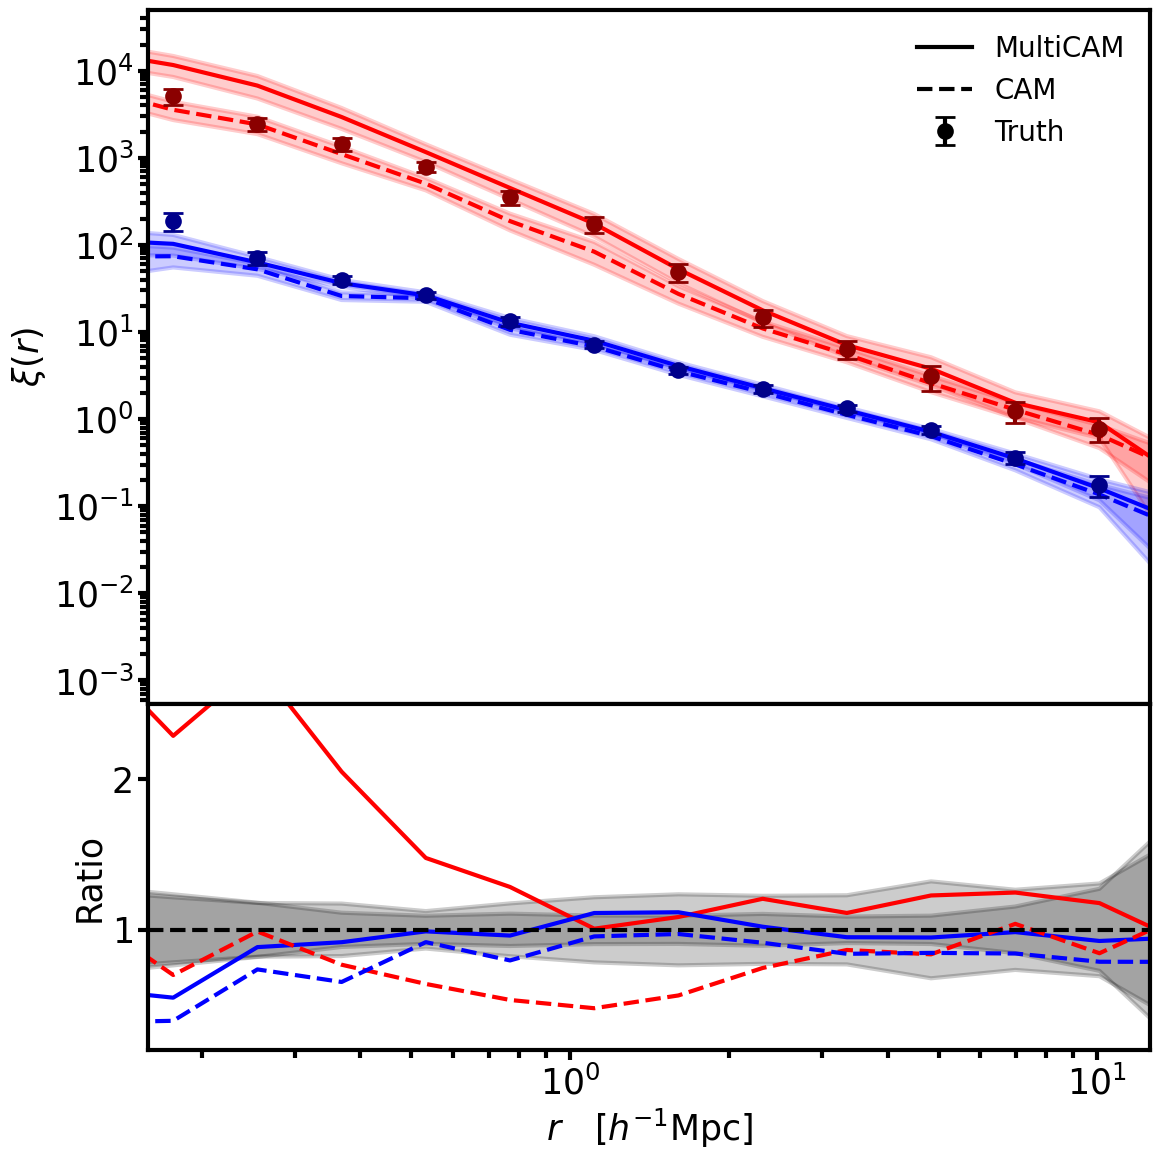

In [18]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(
    2, 1,
    figsize=(12, 12),
    sharex=True,
    gridspec_kw={
        'height_ratios': [2, 1],
        'hspace': 0
    }
)
# ---------------- Top panel ----------------

#####################################

axes[0].plot(
    rbin_centers, xi_red_pred,
    color='red', linewidth=3
)
axes[0].fill_between(
    rbin_centers,
    xi_red_pred - np.sqrt(np.diag(cov_red_pred)),
    xi_red_pred + np.sqrt(np.diag(cov_red_pred)),
    color='red', alpha=0.2, linewidth=3
)

#####################################

axes[0].plot(
    rbin_centers, xi_blue_pred,
    color='blue', linewidth=3
)
axes[0].fill_between(
    rbin_centers,
    xi_blue_pred - np.sqrt(np.diag(cov_blue_pred)),
    xi_blue_pred + np.sqrt(np.diag(cov_blue_pred)),
    color='blue', alpha=0.2, linewidth=3
)

#####################################

axes[0].plot(
    rbin_centers, xi_red_cam,
    color='red', linestyle = '--', linewidth=3
)
axes[0].fill_between(
    rbin_centers,
    xi_red_cam - np.sqrt(np.diag(cov_red_cam)),
    xi_red_cam + np.sqrt(np.diag(cov_red_cam)),
    color='red', alpha=0.2, linewidth=3
)

#####################################

axes[0].plot(
    rbin_centers, xi_blue_cam,
    color='blue', linestyle = '--', linewidth=3
)
axes[0].fill_between(
    rbin_centers,
    xi_blue_cam - np.sqrt(np.diag(cov_blue_cam)),
    xi_blue_cam + np.sqrt(np.diag(cov_blue_cam)),
    color='blue', alpha=0.2, linewidth=3
)

###################################################



# Common errorbar style
err_kwargs = dict(
    fmt='o',
    markersize=10,
    color='darkred',
    elinewidth=3,
    capsize=7,
    capthick=3,
    markeredgewidth=2,
    alpha=1.0
)

axes[0].errorbar(
    rbin_centers, xi_red_truth,
    yerr=np.sqrt(np.diag(cov_red_truth)),
    **err_kwargs
)


# Common errorbar style
err_kwargs = dict(
    fmt='o',
    markersize=10,
    color='darkblue',
    elinewidth=3,
    capsize=7,
    capthick=3,
    markeredgewidth=2,
    alpha=1.0
)

axes[0].errorbar(
    rbin_centers, xi_blue_truth,
    yerr=np.sqrt(np.diag(cov_blue_truth)),
    **err_kwargs
)


################################

# --- Proxy handles ---
multicam_handle = Line2D(
    [0], [0],
    color='black',
    lw=3,
    linestyle='-',
    label='MultiCAM'
)

cam_handle = Line2D(
    [0], [0],
    color='black',
    lw=3,
    linestyle='--',
    label='CAM'
)

# Errorbar proxy (this MUST be created with errorbar)
truth_handle = axes[0].errorbar(
    [0], [0],
    yerr=[0.3],          # arbitrary nonzero value
    fmt='o',
    color='black',
    markersize=10,
    elinewidth=3,
    capsize=7,
    capthick=3,
    markeredgewidth=2,
    label='Truth'
)

# --- Legend ---
axes[0].legend(
    handles=[multicam_handle, cam_handle, truth_handle],
    frameon=False,
    fontsize=20
)


axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlim(10**(-0.8), 10**(1.1)) # Based on Hadzhiyska
axes[0].set_ylabel(r'$\xi(r)$')

# ---------------- Bottom panel ----------------
axes[1].plot(
    rbin_centers, xi_red_pred / xi_red_truth, color = "red", linewidth=3, label = 'MultiCAM Red'
)

axes[1].plot(
    rbin_centers, xi_blue_pred / xi_blue_truth, color = "blue", linewidth=3, label = 'MultiCAM Blue'
)

axes[1].plot(
    rbin_centers, xi_red_cam / xi_red_truth, color = "red", linestyle='--', linewidth=3, label = 'CAM Red'
)

axes[1].plot(
    rbin_centers, xi_blue_cam / xi_blue_truth, color = "blue", linestyle='--', linewidth=3, label = 'CAM Blue'
)

axes[1].fill_between(
    rbin_centers,
    1 - (np.sqrt(np.diag(cov_blue_truth))/xi_blue_truth),
    1 + (np.sqrt(np.diag(cov_blue_truth))/xi_blue_truth),
    color='k', alpha=0.2, linewidth=3
)

axes[1].fill_between(
    rbin_centers,
    1 - (np.sqrt(np.diag(cov_red_truth))/xi_red_truth),
    1 + (np.sqrt(np.diag(cov_red_truth))/xi_red_truth),
    color='k', alpha=0.2, linewidth=3
)



axes[1].axhline(1.0, color='black', linestyle='--', linewidth=3)
axes[1].set_xlabel(r'$r \quad [h^{-1} \rm Mpc]$')
axes[1].set_ylabel('Ratio')
axes[1].set_ylim(0.2, 2.5)

# ---------------- Final formatting ----------------
plt.tight_layout()
fig.savefig('multicam_hydro_mah_noscatter_sham.png', dpi=300, bbox_inches='tight')
plt.show()